# P8-1 Historical Delivered-Rate Benchmark

This notebook creates the first P8 uncertainty anchor requested after the 17 July meeting: a historical benchmark for UK economy-wide emissions reduction rates.

**Purpose:** compare DESNZ current-policy and CCC target-consistent future rates with historically delivered UK territorial greenhouse-gas reduction rates.

**Outputs produced by this notebook:**

- `p8_1_historical_total_emissions.csv`
- `p8_1_historical_rate_windows.csv`
- `p8_1_future_pathway_rate_comparison.csv`
- `p8_1_historical_vs_future_pathways.jpg`
- `p8_1_rate_benchmark_comparison.jpg`
- `p8_1_results_summary_bilingual.txt`

**Important boundary note:** the official historical series used here is UK territorial greenhouse gas emissions. It is therefore best interpreted as a delivered-rate benchmark, not as a perfect accounting-boundary match to every future pathway, especially where future pathways include international aviation and shipping.

In [1]:
from pathlib import Path
import re
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def find_project_root(start=None):
    # Find a project folder containing Data_raw and the P5 cleaned table.
    candidates = []
    if start is not None:
        candidates.append(Path(start).resolve())
    try:
        candidates.append(Path.cwd().resolve())
    except Exception:
        pass
    candidates += [
        Path(r"E:\UCL Final Essay"),
        Path.home() / "Downloads",
    ]

    checked = []
    for base in candidates:
        for candidate in [base] + list(base.parents):
            if candidate in checked:
                continue
            checked.append(candidate)
            if (candidate / "Data_raw").exists() and (candidate / "p4_p5_local_reproduction" / "tables").exists():
                return candidate
    raise FileNotFoundError(
        "Could not find the dissertation project root. "
        "Please run this notebook from inside the project folder or set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "Data_raw"
P5_TABLE_DIR = PROJECT_ROOT / "p4_p5_local_reproduction" / "tables"
OUTPUT_ROOT = PROJECT_ROOT / "p8_uncertainty_framework"
RAW_CACHE = OUTPUT_ROOT / "data_raw"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"

for folder in [RAW_CACHE, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_ROOT)

Project root: E:\UCL Final Essay
Output folder: E:\UCL Final Essay\p8_uncertainty_framework


## 1. Source Files

The notebook uses GOV.UK/DESNZ `.xlsx` data tables for historical territorial emissions. It also reads the already-cleaned P5 table for DESNZ and CCC future pathway values.

The code downloads the latest official files only if they are not already cached locally.

In [2]:
official_sources = pd.DataFrame(
    [
        {
            "source": "DESNZ final UK GHG emissions statistics 1990-2024",
            "use": "Historical territorial GHG emissions to 2024",
            "url": "https://assets.publishing.service.gov.uk/media/6982294819d3abdb495f37ce/final-greenhouse-gas-emissions-tables-2024.xlsx",
            "local_file": "final-greenhouse-gas-emissions-tables-2024.xlsx",
        },
        {
            "source": "DESNZ provisional UK GHG emissions statistics 2025",
            "use": "Provisional 2025 territorial GHG estimate",
            "url": "https://assets.publishing.service.gov.uk/media/69ccdb9ab50f8f8dfb8559b3/2025-provisional-greenhouse-gas-emissions-statistics-data-tables.xlsx",
            "local_file": "2025-provisional-greenhouse-gas-emissions-statistics-data-tables.xlsx",
        },
        {
            "source": "P5 cleaned DESNZ/CCC benchmark table",
            "use": "Future baseline and target-consistent pathway values",
            "url": "local project file",
            "local_file": str(P5_TABLE_DIR / "p5_cleaned_benchmark_year_gap_metrics.csv"),
        },
    ]
)

display(official_sources)


def download_if_missing(url, out_path):
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"Using cached file: {out_path.name}")
        return out_path
    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, out_path)
    print(f"Saved: {out_path}")
    return out_path


final_2024_path = download_if_missing(
    official_sources.loc[0, "url"],
    RAW_CACHE / official_sources.loc[0, "local_file"],
)
provisional_2025_path = download_if_missing(
    official_sources.loc[1, "url"],
    RAW_CACHE / official_sources.loc[1, "local_file"],
)
p5_path = Path(official_sources.loc[2, "local_file"])

assert p5_path.exists(), f"Cannot find P5 cleaned table: {p5_path}"

,source,use,url,local_file
0,DESNZ final UK GHG emissions statistics 1990-2024,Historical territorial GHG emissions to 2024,https://assets.publishing.service.gov.uk/media...,final-greenhouse-gas-emissions-tables-2024.xlsx
1,DESNZ provisional UK GHG emissions statistics ...,Provisional 2025 territorial GHG estimate,https://assets.publishing.service.gov.uk/media...,2025-provisional-greenhouse-gas-emissions-stat...
2,P5 cleaned DESNZ/CCC benchmark table,Future baseline and target-consistent pathway ...,local project file,E:\UCL Final Essay\p4_p5_local_reproduction\ta...


Using cached file: final-greenhouse-gas-emissions-tables-2024.xlsx
Using cached file: 2025-provisional-greenhouse-gas-emissions-statistics-data-tables.xlsx


## 2. Extract Historical UK Territorial Emissions

The 2025 provisional workbook contains an annual territorial GHG table. It includes 1990-2024 values consistent with the 1990-2024 inventory and adds a provisional 2025 value.

In [3]:
def parse_year(value):
    # Parse columns like 1990, 2024.0, or '2025 [p]'.
    if pd.isna(value):
        return None
    match = re.search(r"(19|20)\d{2}", str(value))
    return int(match.group(0)) if match else None


def extract_total_territorial_from_2025_workbook(path):
    df = pd.read_excel(path, sheet_name="1a_GHG", header=None)
    header_idx = df.index[df.iloc[:, 0].astype(str).str.strip().eq("TES sector")][0]
    total_rows = df.index[df.iloc[:, 0].astype(str).str.strip().eq("Total greenhouse gas emissions")]
    if len(total_rows) == 0:
        raise ValueError("Could not find Total greenhouse gas emissions row in 2025 workbook.")
    total_idx = total_rows[0]  # first total row = unadjusted annual emissions

    records = []
    for col in range(1, df.shape[1]):
        year = parse_year(df.iat[header_idx, col])
        value = df.iat[total_idx, col]
        if year is not None and pd.notna(value):
            records.append(
                {
                    "year": year,
                    "historical_total_territorial_MtCO2e": float(value),
                    "data_status": "provisional" if year == 2025 else "final/inventory-consistent",
                }
            )
    out = pd.DataFrame(records).drop_duplicates("year").sort_values("year")
    if out["year"].max() < 2025:
        raise ValueError("2025 provisional value was not extracted.")
    return out


historical = extract_total_territorial_from_2025_workbook(provisional_2025_path)
historical.to_csv(TABLE_DIR / "p8_1_historical_total_emissions.csv", index=False)

display(historical.tail(10))
print("Historical years:", historical["year"].min(), "-", historical["year"].max())
print("2025 provisional total:", round(historical.loc[historical["year"].eq(2025), "historical_total_territorial_MtCO2e"].iloc[0], 1), "MtCO2e")

,year,historical_total_territorial_MtCO2e,data_status
26,2016,483.211615,final/inventory-consistent
27,2017,471.821974,final/inventory-consistent
28,2018,464.054220,final/inventory-consistent
29,2019,447.513593,final/inventory-consistent
30,2020,407.536085,final/inventory-consistent
31,2021,422.192907,final/inventory-consistent
32,2022,403.967534,final/inventory-consistent
33,2023,383.934828,final/inventory-consistent
34,2024,373.400251,final/inventory-consistent
35,2025,366.583173,provisional


Historical years: 1990 - 2025
2025 provisional total: 366.6 MtCO2e


## 3. Calculate Historical Delivered Reduction Rates

These windows are chosen to match Neil's advice:

- 1990-2025: long-run delivered UK reduction rate.
- 2008-2025: post-Climate Change Act period.
- 2018-2025: period after the net-zero target entered the policy debate.
- 2019-2025: recent pre-pandemic-to-current window, included as a cautious check.

Positive values mean annual emissions reduction in MtCO2e per year.

In [4]:
def value_for_year(df, year):
    return float(df.loc[df["year"].eq(year), "historical_total_territorial_MtCO2e"].iloc[0])


rate_windows = [
    (1990, 2025, "Long-run historical benchmark"),
    (2008, 2025, "Post-Climate Change Act benchmark"),
    (2018, 2025, "Recent net-zero-era benchmark"),
    (2019, 2025, "Recent pre-pandemic-to-current check"),
]

records = []
for start, end, label in rate_windows:
    start_value = value_for_year(historical, start)
    end_value = value_for_year(historical, end)
    years = end - start
    avg_reduction = (start_value - end_value) / years
    implied_zero_year = end + end_value / avg_reduction if avg_reduction > 0 else np.nan
    records.append(
        {
            "window": f"{start}-{end}",
            "interpretive_label": label,
            "start_year": start,
            "end_year": end,
            "start_emissions_MtCO2e": start_value,
            "end_emissions_MtCO2e": end_value,
            "absolute_reduction_MtCO2e": start_value - end_value,
            "avg_annual_reduction_MtCO2e_per_year": avg_reduction,
            "implied_zero_year_if_linear_continues": implied_zero_year,
            "method_note": "Linear delivered-rate benchmark; not a forecast.",
        }
    )

historical_rates = pd.DataFrame(records)
historical_rates.to_csv(TABLE_DIR / "p8_1_historical_rate_windows.csv", index=False)
display(historical_rates.round(2))

,window,interpretive_label,start_year,end_year,start_emissions_MtCO2e,end_emissions_MtCO2e,absolute_reduction_MtCO2e,avg_annual_reduction_MtCO2e_per_year,implied_zero_year_if_linear_continues,method_note
0,1990-2025,Long-run historical benchmark,1990,2025,790.82,366.58,424.24,12.12,2055.24,Linear delivered-rate benchmark; not a forecast.
1,2008-2025,Post-Climate Change Act benchmark,2008,2025,652.68,366.58,286.09,16.83,2046.78,Linear delivered-rate benchmark; not a forecast.
2,2018-2025,Recent net-zero-era benchmark,2018,2025,464.05,366.58,97.47,13.92,2051.33,Linear delivered-rate benchmark; not a forecast.
3,2019-2025,Recent pre-pandemic-to-current check,2019,2025,447.51,366.58,80.93,13.49,2052.18,Linear delivered-rate benchmark; not a forecast.


## 4. Compare DESNZ and CCC Future Rates with Historical Rates

This is the core P8-1 test. It asks whether each future period requires reductions slower than, similar to, or faster than historically delivered rates.

In [5]:
p5 = pd.read_csv(p5_path)
p5 = p5.sort_values("year")
display(p5)


future_series = {
    "DESNZ current-policy baseline excluding IAS": "DESNZ_EEP_2024_excl_IAS_MtCO2e",
    "DESNZ current-policy baseline including IAS": "DESNZ_EEP_2024_inc_IAS_MtCO2e",
    "CCC Seventh Carbon Budget Balanced Pathway": "CCC7_Balanced_Pathway_MtCO2e",
}

periods = [(2025, 2030), (2030, 2035), (2035, 2050)]
comparison_records = []

long_rate = historical_rates.loc[historical_rates["window"].eq("1990-2025"), "avg_annual_reduction_MtCO2e_per_year"].iloc[0]
recent_rate = historical_rates.loc[historical_rates["window"].eq("2018-2025"), "avg_annual_reduction_MtCO2e_per_year"].iloc[0]

for pathway, col in future_series.items():
    for start, end in periods:
        start_value = float(p5.loc[p5["year"].eq(start), col].iloc[0])
        end_value = float(p5.loc[p5["year"].eq(end), col].iloc[0])
        avg_reduction = (start_value - end_value) / (end - start)
        ratio_to_long = avg_reduction / long_rate if long_rate != 0 else np.nan
        ratio_to_recent = avg_reduction / recent_rate if recent_rate != 0 else np.nan

        if avg_reduction < 0:
            judgement = "emissions increase in this period"
        elif ratio_to_recent < 0.5:
            judgement = "much slower than recent historical delivery"
        elif ratio_to_recent <= 1.25:
            judgement = "broadly comparable to recent historical delivery"
        else:
            judgement = "faster than recent historical delivery"

        comparison_records.append(
            {
                "pathway": pathway,
                "period": f"{start}-{end}",
                "start_emissions_MtCO2e": start_value,
                "end_emissions_MtCO2e": end_value,
                "avg_annual_reduction_MtCO2e_per_year": avg_reduction,
                "ratio_to_1990_2025_historical_rate": ratio_to_long,
                "ratio_to_2018_2025_historical_rate": ratio_to_recent,
                "interpretive_judgement": judgement,
            }
        )

future_rate_comparison = pd.DataFrame(comparison_records)
future_rate_comparison.to_csv(TABLE_DIR / "p8_1_future_pathway_rate_comparison.csv", index=False)
display(future_rate_comparison.round(2))

,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e,CCC7_Balanced_Pathway_MtCO2e,CCC6_Balanced_Net_Zero_Pathway_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e,gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e
0,2025,363.150083,405.820995,413.919333,445.268932,-8.098338,-39.447937,-50.769250
1,2030,327.713982,367.969033,295.757071,316.267362,72.211962,51.701671,31.956911
2,2035,303.407284,341.791617,186.996305,190.910771,154.795312,150.880846,116.410979
3,2040,287.413756,323.989470,107.703015,104.519508,216.286455,219.469962,179.710742
4,2045,286.723569,323.462890,42.467539,37.766350,280.995351,285.696540,244.256030
5,2050,290.244906,324.291346,-1.107090,-0.972447,325.398436,325.263793,291.351996


,pathway,period,start_emissions_MtCO2e,end_emissions_MtCO2e,avg_annual_reduction_MtCO2e_per_year,ratio_to_1990_2025_historical_rate,ratio_to_2018_2025_historical_rate,interpretive_judgement
0,DESNZ current-policy baseline excluding IAS,2025-2030,363.15,327.71,7.09,0.58,0.51,broadly comparable to recent historical delivery
1,DESNZ current-policy baseline excluding IAS,2030-2035,327.71,303.41,4.86,0.40,0.35,much slower than recent historical delivery
2,DESNZ current-policy baseline excluding IAS,2035-2050,303.41,290.24,0.88,0.07,0.06,much slower than recent historical delivery
3,DESNZ current-policy baseline including IAS,2025-2030,405.82,367.97,7.57,0.62,0.54,broadly comparable to recent historical delivery
4,DESNZ current-policy baseline including IAS,2030-2035,367.97,341.79,5.24,0.43,0.38,much slower than recent historical delivery
5,DESNZ current-policy baseline including IAS,2035-2050,341.79,324.29,1.17,0.10,0.08,much slower than recent historical delivery
6,CCC Seventh Carbon Budget Balanced Pathway,2025-2030,413.92,295.76,23.63,1.95,1.70,faster than recent historical delivery
7,CCC Seventh Carbon Budget Balanced Pathway,2030-2035,295.76,187.00,21.75,1.79,1.56,faster than recent historical delivery
8,CCC Seventh Carbon Budget Balanced Pathway,2035-2050,187.00,-1.11,12.54,1.03,0.90,broadly comparable to recent historical delivery


## 5. Visualise the Historical Benchmark and Future Pathways

The figures are saved as `.jpg` files to avoid PNG rendering issues.

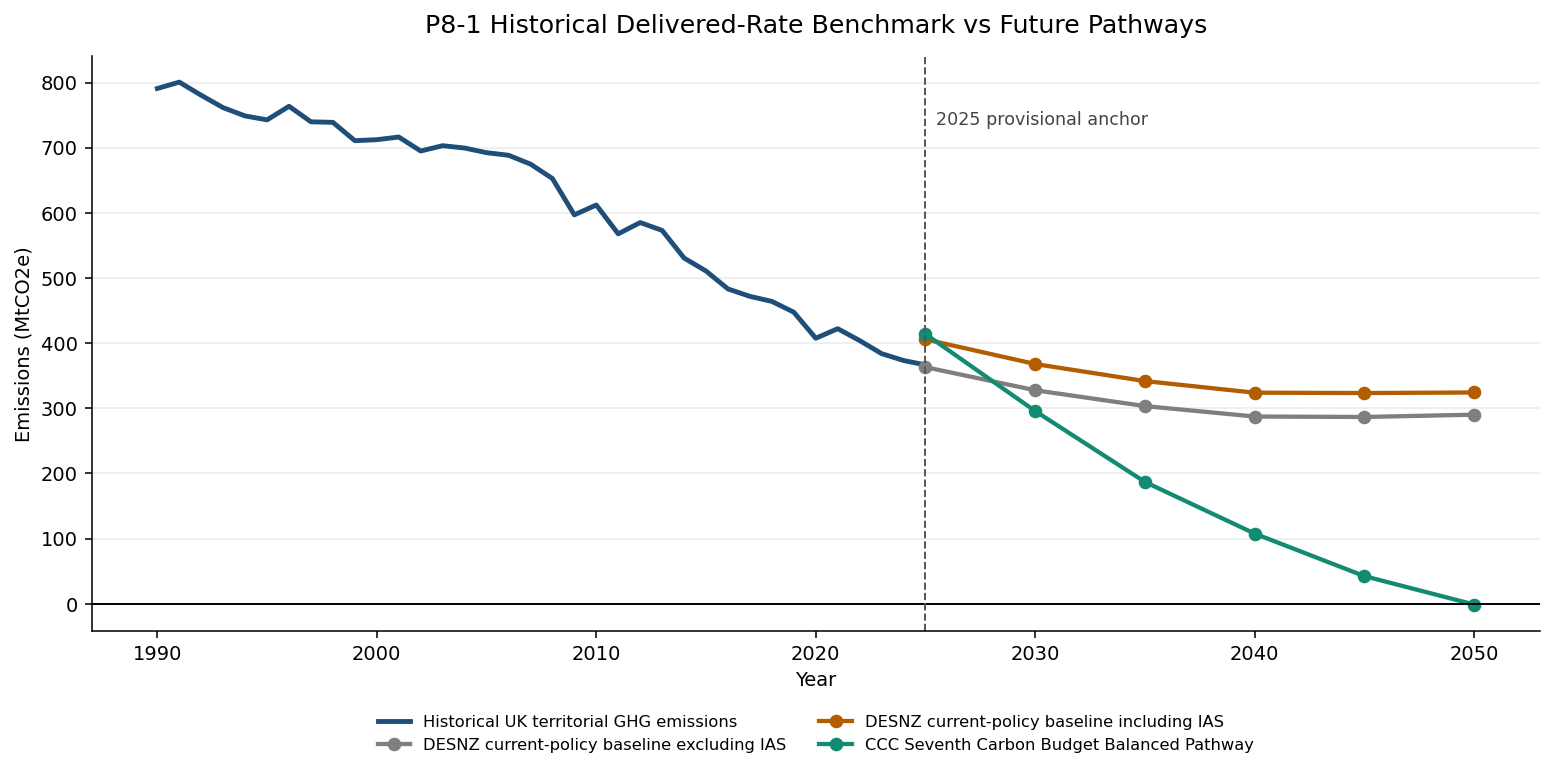

Saved: E:\UCL Final Essay\p8_uncertainty_framework\figures\p8_1_historical_vs_future_pathways.jpg


In [6]:
fig, ax = plt.subplots(figsize=(11.2, 6.2))

ax.plot(
    historical["year"],
    historical["historical_total_territorial_MtCO2e"],
    color="#1f4e79",
    linewidth=2.5,
    label="Historical UK territorial GHG emissions",
)

colors = {
    "DESNZ current-policy baseline excluding IAS": "#7f7f7f",
    "DESNZ current-policy baseline including IAS": "#b35c00",
    "CCC Seventh Carbon Budget Balanced Pathway": "#138a72",
}

for pathway, col in future_series.items():
    ax.plot(
        p5["year"],
        p5[col],
        marker="o",
        linewidth=2.2,
        color=colors[pathway],
        label=pathway,
    )

ax.axhline(0, color="black", linewidth=1)
ax.axvline(2025, color="#555555", linestyle="--", linewidth=1)
ax.text(2025.5, 735, "2025 provisional anchor", fontsize=9, color="#444444")

ax.set_title("P8-1 Historical Delivered-Rate Benchmark vs Future Pathways", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Emissions (MtCO2e)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=8.4)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig_path_1 = FIG_DIR / "p8_1_historical_vs_future_pathways.jpg"
fig.savefig(fig_path_1, format="jpg", bbox_inches="tight")
plt.show()

print("Saved:", fig_path_1)

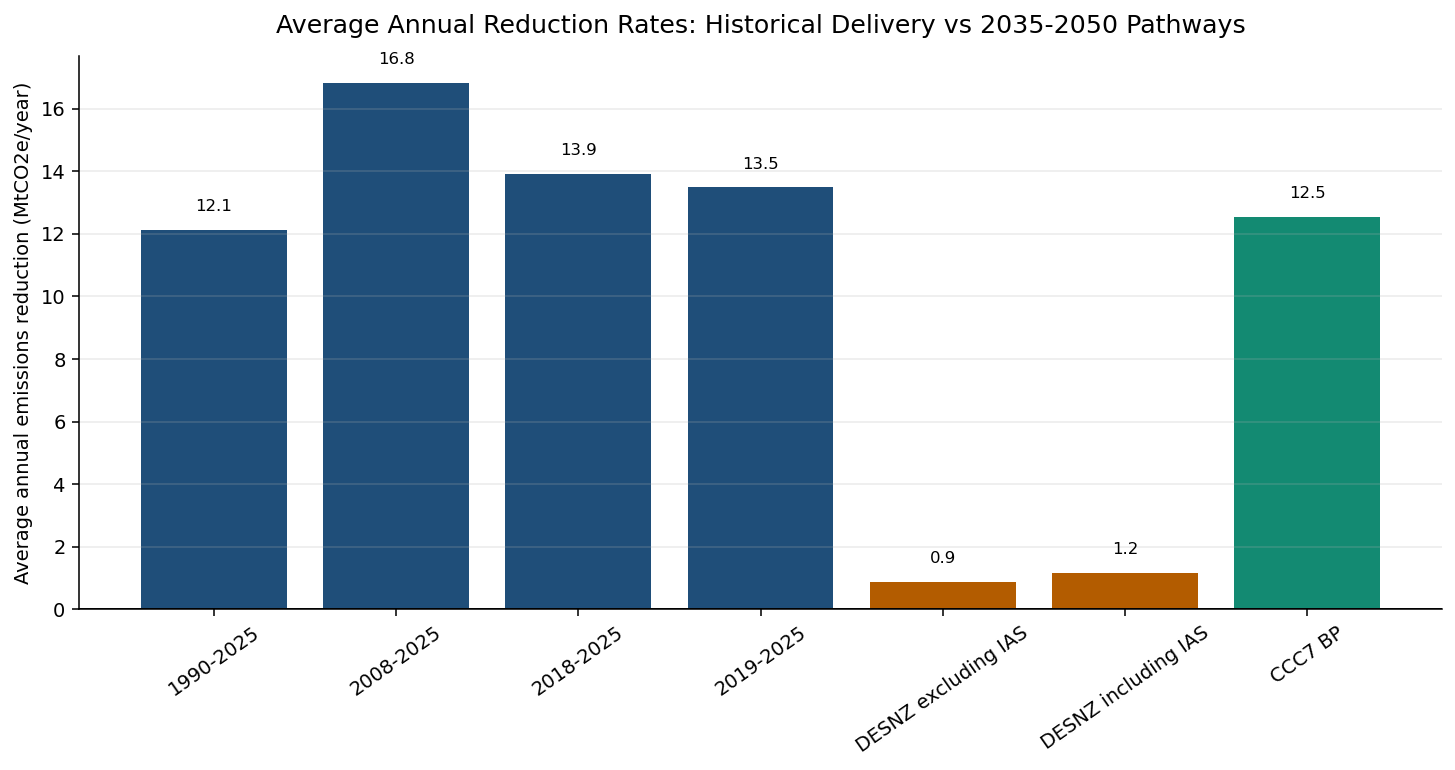

Saved: E:\UCL Final Essay\p8_uncertainty_framework\figures\p8_1_rate_benchmark_comparison.jpg


In [7]:
rate_plot_records = []
for _, row in historical_rates.iterrows():
    rate_plot_records.append(
        {
            "label": row["window"],
            "group": "Historical delivered rates",
            "rate": row["avg_annual_reduction_MtCO2e_per_year"],
        }
    )

selected_future = future_rate_comparison[
    future_rate_comparison["period"].isin(["2035-2050"])
].copy()
for _, row in selected_future.iterrows():
    short_name = row["pathway"].replace(" current-policy baseline", "").replace(" Seventh Carbon Budget Balanced Pathway", "7 BP")
    rate_plot_records.append(
        {
            "label": short_name,
            "group": "Future 2035-2050 rates",
            "rate": row["avg_annual_reduction_MtCO2e_per_year"],
        }
    )

rate_plot = pd.DataFrame(rate_plot_records)
bar_colors = ["#1f4e79" if g == "Historical delivered rates" else "#b35c00" if "DESNZ" in l else "#138a72" for g, l in zip(rate_plot["group"], rate_plot["label"])]

fig, ax = plt.subplots(figsize=(10.5, 5.6))
bars = ax.bar(rate_plot["label"], rate_plot["rate"], color=bar_colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Average Annual Reduction Rates: Historical Delivery vs 2035-2050 Pathways", fontsize=13, pad=12)
ax.set_ylabel("Average annual emissions reduction (MtCO2e/year)")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.5 if height >= 0 else -1.0),
        f"{height:.1f}",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=8.5,
    )

fig.tight_layout()
fig_path_2 = FIG_DIR / "p8_1_rate_benchmark_comparison.jpg"
fig.savefig(fig_path_2, format="jpg", bbox_inches="tight")
plt.show()

print("Saved:", fig_path_2)

## 6. Bilingual Results Summary

This text is deliberately short. It can later be turned into a Results or Discussion subsection.

In [8]:
hist_1990_2025 = historical_rates.loc[historical_rates["window"].eq("1990-2025")].iloc[0]
hist_2018_2025 = historical_rates.loc[historical_rates["window"].eq("2018-2025")].iloc[0]

desnz_2035_2050 = future_rate_comparison[
    (future_rate_comparison["pathway"].eq("DESNZ current-policy baseline including IAS"))
    & (future_rate_comparison["period"].eq("2035-2050"))
].iloc[0]
ccc_2035_2050 = future_rate_comparison[
    (future_rate_comparison["pathway"].eq("CCC Seventh Carbon Budget Balanced Pathway"))
    & (future_rate_comparison["period"].eq("2035-2050"))
].iloc[0]

summary_en = f'''
P8-1 result summary

The historical benchmark suggests that the UK reduced territorial greenhouse gas emissions by an average of {hist_1990_2025['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e/year between 1990 and 2025, and by {hist_2018_2025['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e/year between 2018 and 2025. This gives a delivered-rate benchmark for judging future pathways.

Against this benchmark, the DESNZ current-policy baseline is not simply high in 2050; it also slows sharply after 2035. Its 2035-2050 average annual reduction is only {desnz_2035_2050['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e/year when including IAS, far below the recent historical benchmark. By contrast, the CCC Seventh Carbon Budget Balanced Pathway requires about {ccc_2035_2050['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e/year over 2035-2050, which is demanding but broadly comparable to the economy-wide pace previously delivered over some historical windows.

This does not prove that the CCC pathway is easy or automatically feasible, because earlier reductions benefited from structural changes such as power-sector decarbonisation and easier abatement opportunities. However, it strengthens the interpretation that the DESNZ baseline represents a post-2035 delivery slowdown, while the CCC pathway represents continued delivery at a historically recognisable but sectorally more difficult pace.
'''.strip()

summary_cn = f'''
P8-1 结果总结

历史基准显示，英国1990-2025年的领土口径温室气体排放平均每年下降约 {hist_1990_2025['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e，2018-2025年平均每年下降约 {hist_2018_2025['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e。这个结果可以作为判断未来路径减排速度是否合理的历史参照。

与这个历史参照相比，DESNZ current-policy baseline 的问题不只是2050年残余排放高，而是2035年之后明显放缓。若包含国际航空和航运，其2035-2050年平均每年只下降约 {desnz_2035_2050['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e，显著低于近期历史减排速度。相比之下，CCC 第七碳预算 Balanced Pathway 在2035-2050年需要平均每年下降约 {ccc_2035_2050['avg_annual_reduction_MtCO2e_per_year']:.1f} MtCO2e，这一速度有挑战，但并没有明显超出英国历史上部分时期已经实现过的经济整体减排速度。

这并不意味着CCC路径容易实现，因为过去的减排包含电力部门去煤化等相对较容易的结构性变化，未来剩余部门可能更难减排。但它强化了一个论文判断：DESNZ baseline 体现的是2035年后的delivery slowdown，而CCC路径则代表一种历史上可识别、但部门层面更困难的持续减排速度。
'''.strip()

summary_text = summary_en + "\n\n" + summary_cn
summary_path = TABLE_DIR / "p8_1_results_summary_bilingual.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved:", summary_path)

P8-1 result summary

The historical benchmark suggests that the UK reduced territorial greenhouse gas emissions by an average of 12.1 MtCO2e/year between 1990 and 2025, and by 13.9 MtCO2e/year between 2018 and 2025. This gives a delivered-rate benchmark for judging future pathways.

Against this benchmark, the DESNZ current-policy baseline is not simply high in 2050; it also slows sharply after 2035. Its 2035-2050 average annual reduction is only 1.2 MtCO2e/year when including IAS, far below the recent historical benchmark. By contrast, the CCC Seventh Carbon Budget Balanced Pathway requires about 12.5 MtCO2e/year over 2035-2050, which is demanding but broadly comparable to the economy-wide pace previously delivered over some historical windows.

This does not prove that the CCC pathway is easy or automatically feasible, because earlier reductions benefited from structural changes such as power-sector decarbonisation and easier abatement opportunities. However, it strengthens the inter

## 7. Quick Quality Checks

These checks are not complicated, but they help catch obvious extraction or accounting mistakes.

In [9]:
checks = []

checks.append(
    {
        "check": "historical_year_range",
        "expected": "1990-2025",
        "actual": f"{historical['year'].min()}-{historical['year'].max()}",
        "status": "PASS" if historical["year"].min() == 1990 and historical["year"].max() == 2025 else "CHECK",
    }
)
checks.append(
    {
        "check": "historical_total_declines_1990_2025",
        "expected": "2025 lower than 1990",
        "actual": f"{value_for_year(historical, 1990):.1f} -> {value_for_year(historical, 2025):.1f}",
        "status": "PASS" if value_for_year(historical, 2025) < value_for_year(historical, 1990) else "CHECK",
    }
)
checks.append(
    {
        "check": "p5_required_years_available",
        "expected": "2025, 2030, 2035, 2050",
        "actual": ", ".join(map(str, sorted(set(p5["year"]).intersection({2025, 2030, 2035, 2050})))),
        "status": "PASS" if {2025, 2030, 2035, 2050}.issubset(set(p5["year"])) else "CHECK",
    }
)
checks.append(
    {
        "check": "figures_saved_as_jpg",
        "expected": "2 jpg figures",
        "actual": f"{fig_path_1.exists()} / {fig_path_2.exists()}",
        "status": "PASS" if fig_path_1.exists() and fig_path_2.exists() else "CHECK",
    }
)

quality_checks = pd.DataFrame(checks)
quality_checks.to_csv(TABLE_DIR / "p8_1_quality_checks.csv", index=False)
display(quality_checks)

if not all(quality_checks["status"].eq("PASS")):
    print("One or more checks need attention before using the results in the dissertation.")
else:
    print("All P8-1 quality checks passed.")

,check,expected,actual,status
0,historical_year_range,1990-2025,1990-2025,PASS
1,historical_total_declines_1990_2025,2025 lower than 1990,790.8 -> 366.6,PASS
2,p5_required_years_available,"2025, 2030, 2035, 2050","2025, 2030, 2035, 2050",PASS
3,figures_saved_as_jpg,2 jpg figures,True / True,PASS


All P8-1 quality checks passed.
